<h1 style="text-align:center">Student Performance Regression</h1>

-----------
## Project Purpose

The aim of this project is to build and evaluate regression models for predicting a student's Performance Index.

This notebook is intended purely for learning and experimentation with regression techniques and model evaluation. It is not designed as a complete production-ready or deployable machine-learning system.

-------------
## Data import 

In [4]:
import pandas as pd

In [5]:
data = pd.read_csv("Data.csv")

## Dataset Source and Credit

The dataset used in this project was obtained from **Kaggle** and is used solely for educational and learning purposes. Credit for the dataset goes to its original creator/uploader.

**Dataset:** Student Performance Dataset
**Source:** Kaggle
**Dataset Link:** `https://www.kaggle.com/datasets/nikhil7280/student-performance-multiple-linear-regression?resource=download`

The dataset is synthetic and should not be interpreted as representing real-world student performance relationships.


-----------
## Data inspection and EDA


In [44]:
data.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [45]:
data.shape

(10000, 6)

In [46]:
data.describe()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


In [47]:
data.nunique()

Hours Studied                        9
Previous Scores                     60
Extracurricular Activities           2
Sleep Hours                          6
Sample Question Papers Practiced    10
Performance Index                   91
dtype: int64

In [48]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  str    
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), str(1)
memory usage: 468.9 KB


### Initial Data Inspection Summary

The dataset contains **10,000 rows and 6 columns** and appears clean and easy to interpret. No missing values are present, and only `Extracurricular Activities` is categorical; it can later be mapped from `Yes/No` to `1/0` for modelling.

The numerical summary shows fairly consistent spacing between the minimum, quartiles, median, and maximum values, suggesting no obvious extreme outliers at this stage. This will be checked further using box plots during visualization.

Overall, the dataset is simple, well-structured, and suitable for regression experimentation.


------
## Data Inspection Using Visualization Techniques

In this section, the dataset will be examined visually to better understand the behaviour of the features and their relationship with the target variable, `Performance Index`.

Numerical features will be evaluated using scatter/regression plots and box plots to identify patterns, relationships, and possible outliers. A correlation heatmap will also be used to measure and visualize the numerical relationships between the features and the target.

For the categorical feature, `Extracurricular Activities`, a bar chart will be used to compare its categories and determine whether participation shows any noticeable relationship with student performance.


### Numerical Feature

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

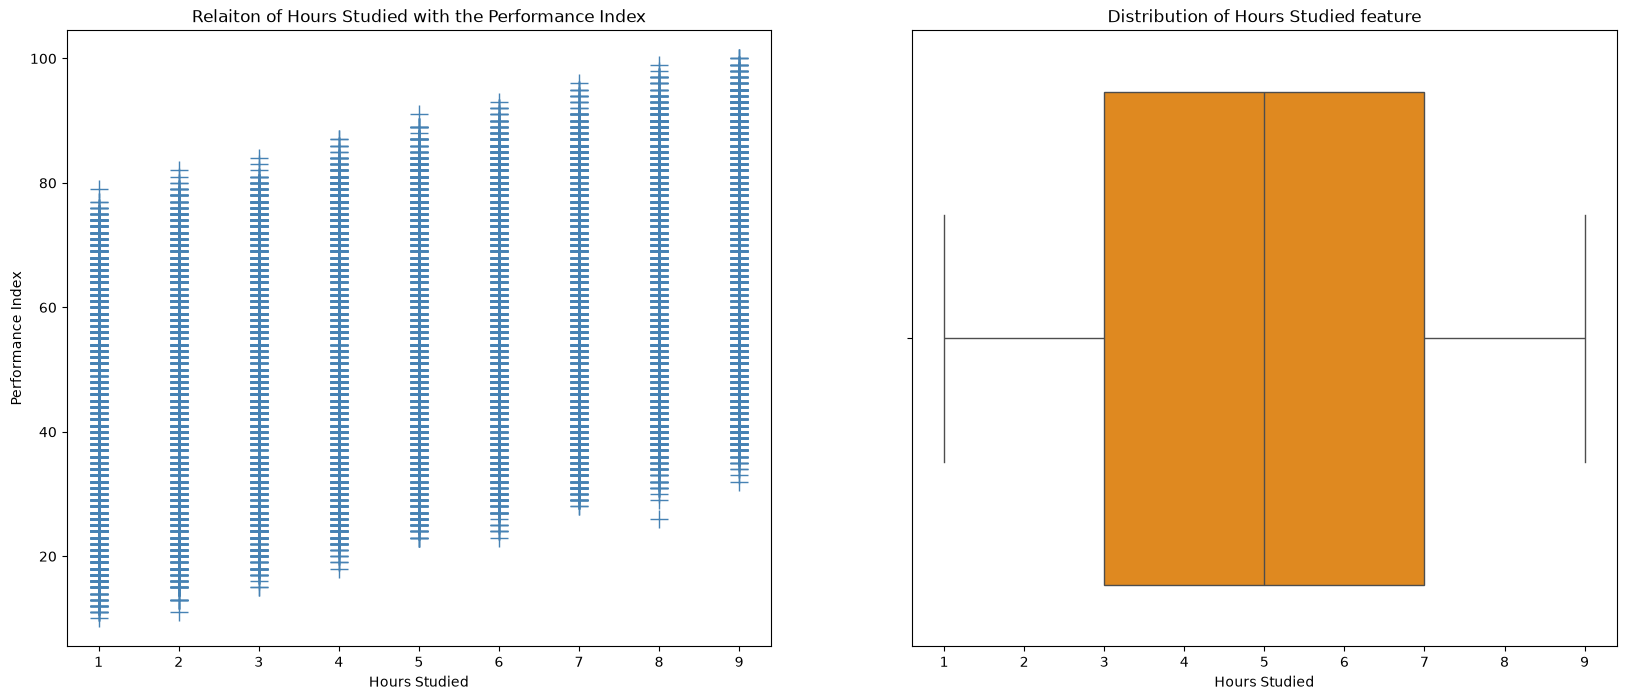

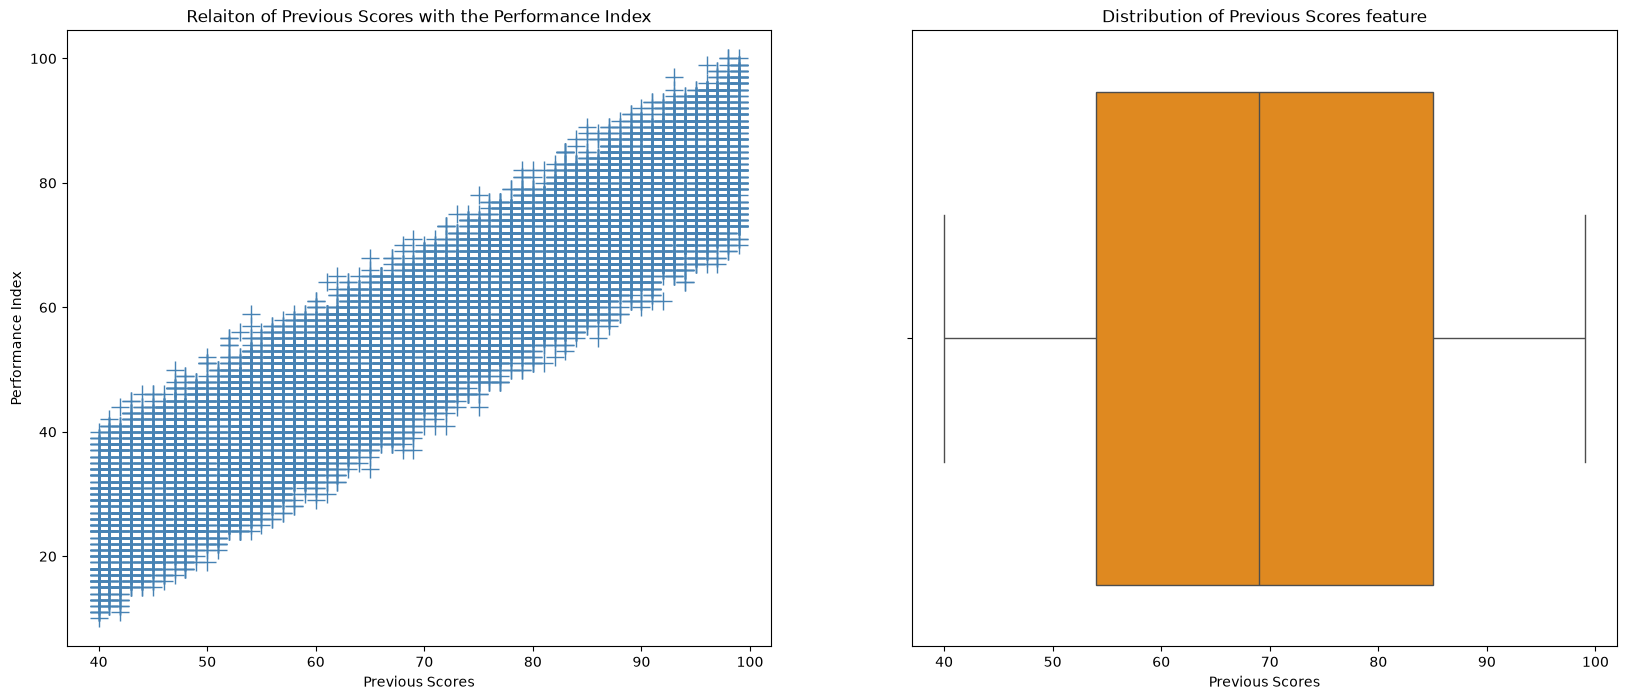

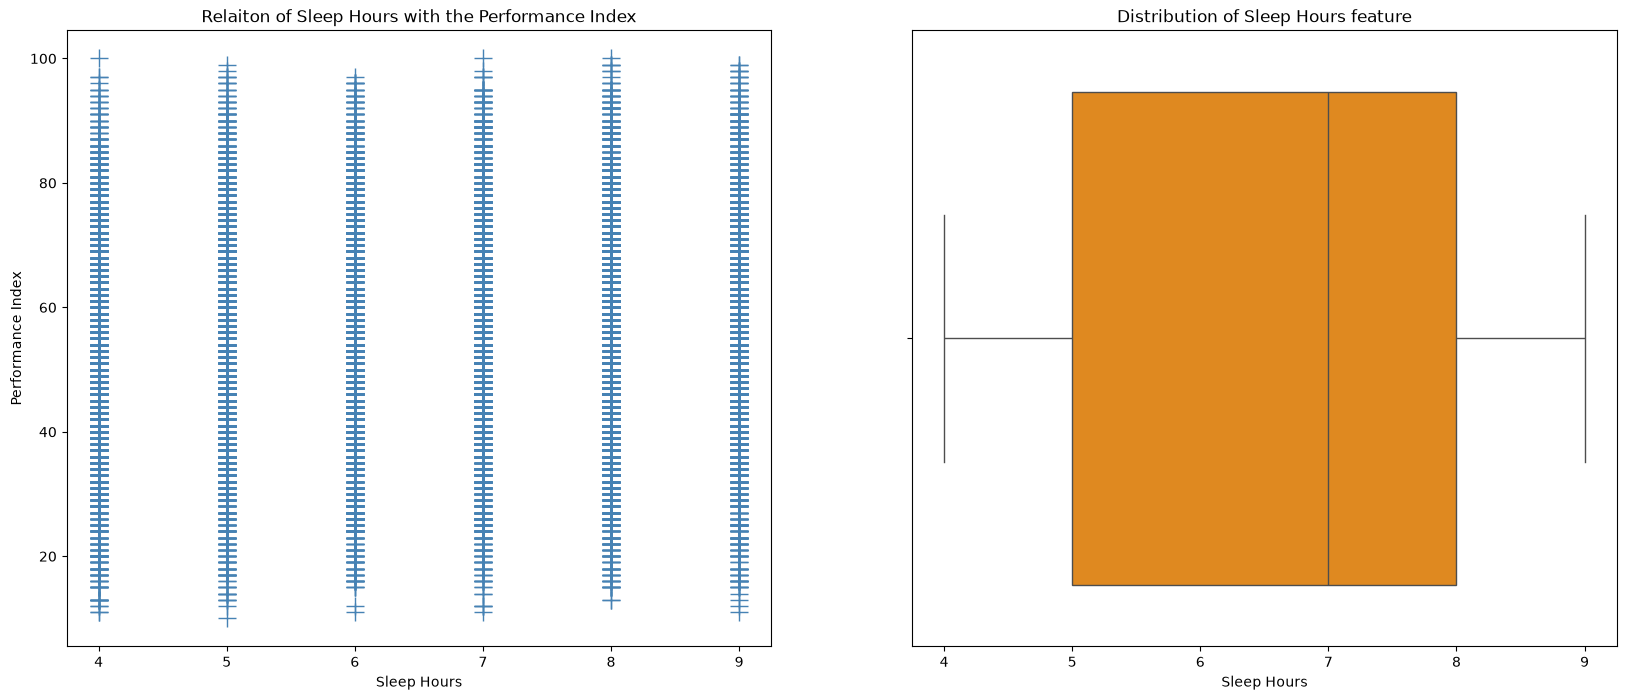

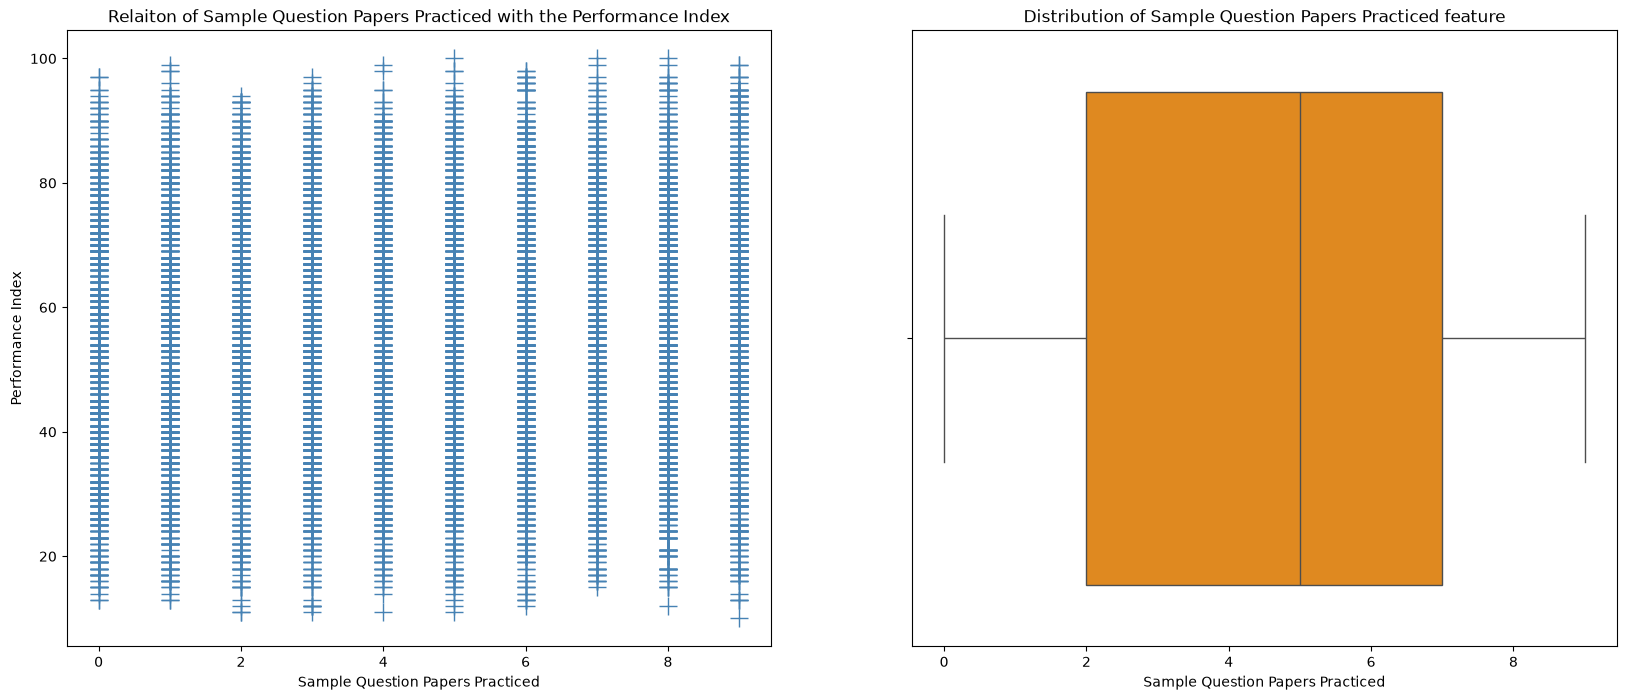

In [18]:
numerical_columns = ['Hours Studied','Previous Scores','Sleep Hours','Sample Question Papers Practiced']
for column in numerical_columns:
    fig = plt.figure(figsize=(20, 8))
    ax0 = fig.add_subplot(1,2,1)
    ax1 = fig.add_subplot(1,2,2)

    sns.scatterplot(data=data, x=column, y="Performance Index", marker="+", color="steelblue",s=160 ,ax=ax0)
    ax0.set_xlabel(column)
    ax0.set_ylabel("Performance Index")
    ax0.set_title(f"Relaiton of {column} with the Performance Index")

    sns.boxplot(data=data, x=column, color="darkorange")
    ax1.set_title(f"Distribution of {column} feature")
    ax1.set_xlabel(column)

    plt.show()


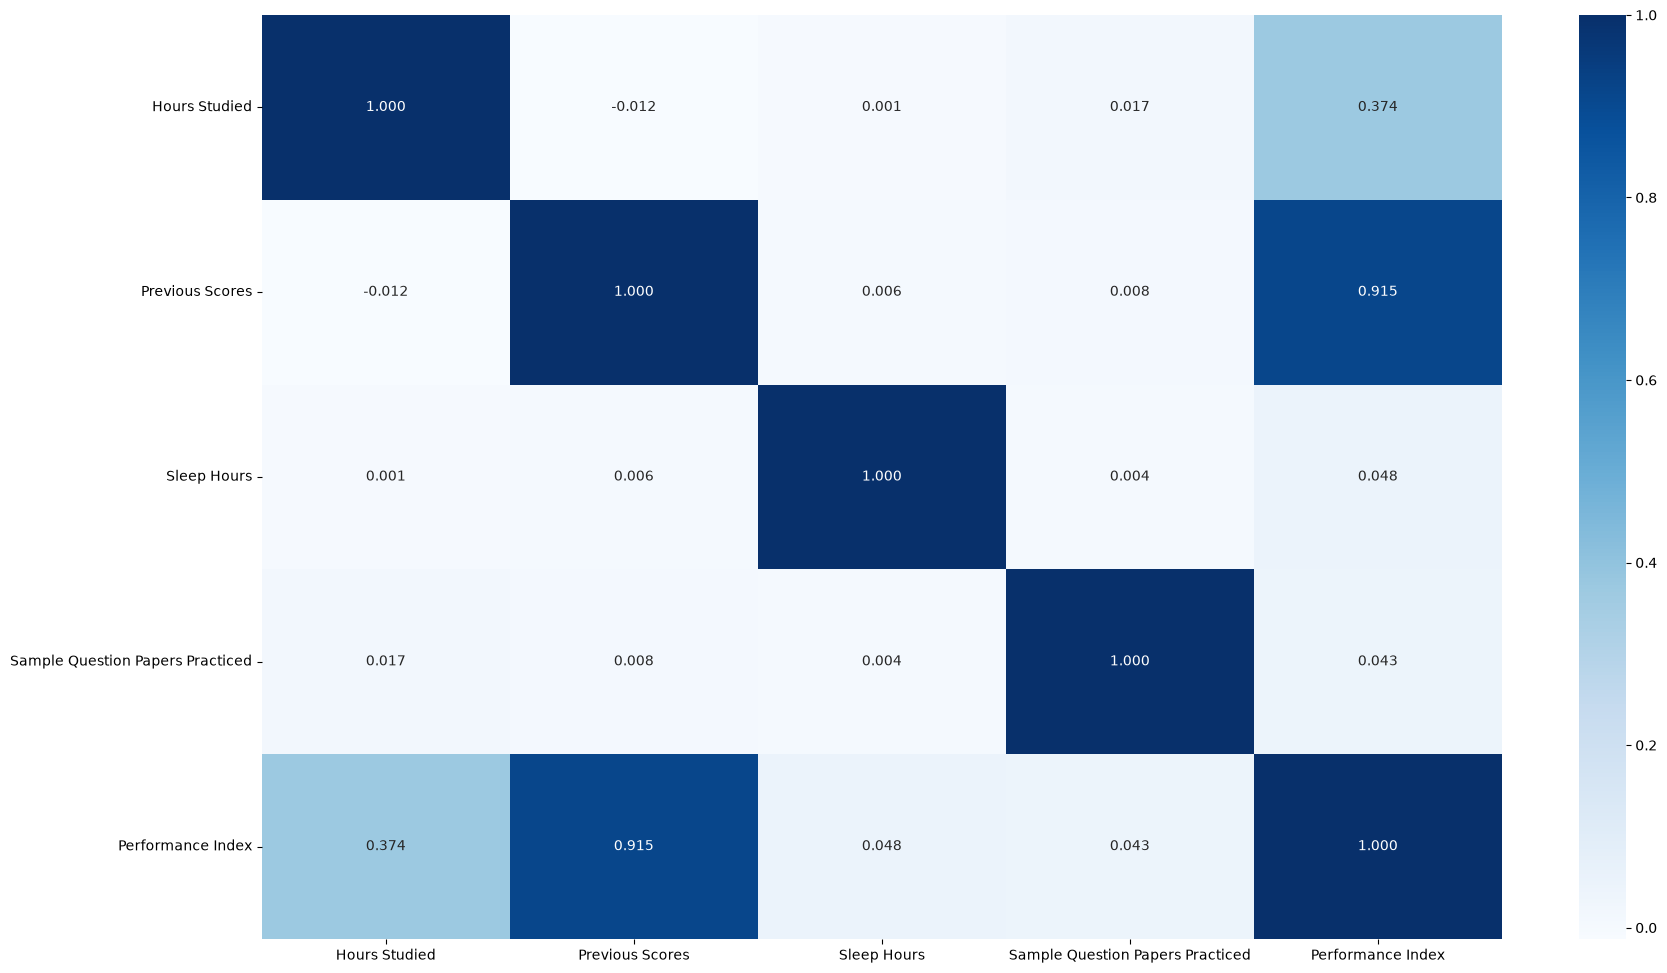

In [20]:
corr_columns = ['Hours Studied','Previous Scores','Sleep Hours','Sample Question Papers Practiced', 'Performance Index']
plt.figure(figsize=(20,12))
sns.heatmap(data[corr_columns].corr(), annot=True, fmt=".3f", cmap="Blues")
plt.show()

### Numerical Feature Evaluation

Among the four numerical features, `Previous Scores` showed the strongest relationship with `Performance Index`, while `Hours Studied` showed a moderate positive relationship. `Sleep Hours` and `Sample Question Papers Practiced` displayed very weak relationships with the target in both the scatter plots and correlation heatmap.

The numerical predictors also showed very little correlation with one another, suggesting no obvious multicollinearity. In addition, the box plots revealed no significant outliers, so no special numerical cleaning is required at this stage.

## Categorical Feature Evaluation

This section will examine `Extracurricular Activities`, the dataset’s only categorical feature. The two categories will be compared against `Performance Index` to determine whether participation in extracurricular activities shows any noticeable relationship with student performance.


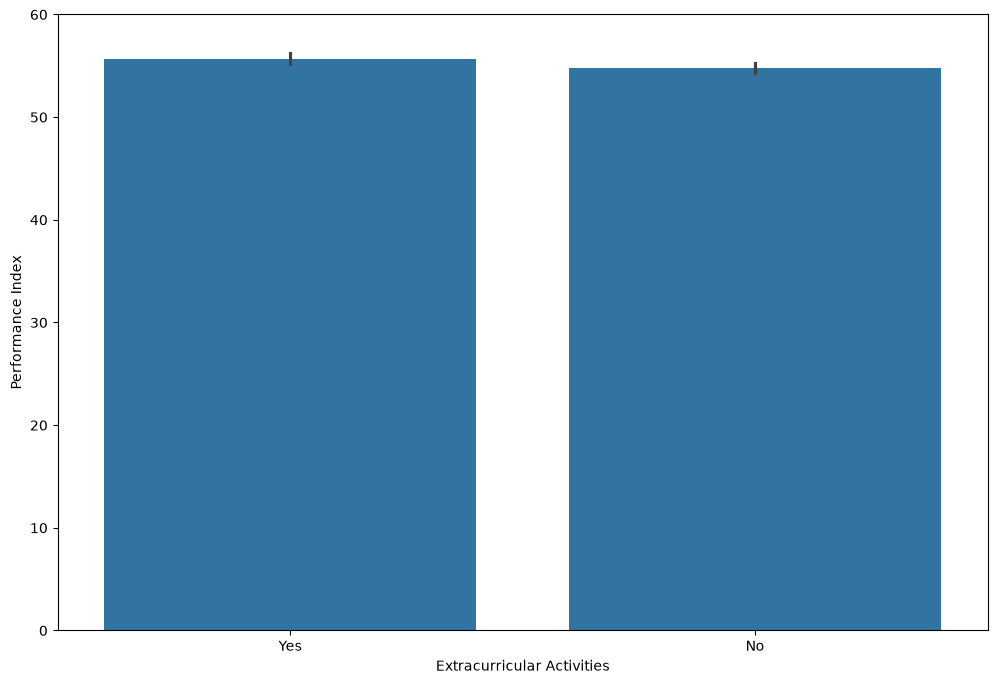

In [24]:
plt.figure(figsize=(12,8))
sns.barplot(data=data, x='Extracurricular Activities', y='Performance Index')
plt.xlabel("Extracurricular Activities")
plt.ylabel('Performance Index')
plt.ylim(0,60)
plt.show()

### Categorical Feature Evaluation

`Extracurricular Activities` showed almost no meaningful difference in average `Performance Index` between students who participated and those who did not. Therefore, no strong categorical relationship was identified from this visualization.


### Overall Feature Evaluation

The EDA showed that `Previous Scores` has the strongest relationship with `Performance Index`, while `Hours Studied` provides a moderate positive relationship. `Sleep Hours`, `Sample Question Papers Practiced`, and `Extracurricular Activities` showed relatively weak individual relationships with the target.

No significant outliers or major data-quality issues were identified. The existing features will therefore be retained for the initial regression model, where their combined predictive contribution can be evaluated before making any feature-selection decisions.


------
## Data Preparation and Model Library Imports

The dataset will now be prepared for regression modelling by converting the categorical feature into numerical form and separating the predictors from the target variable.

The necessary libraries for data splitting, Linear Regression, cross-validation, pipelines, and model evaluation will also be imported before training begins.


In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, accuracy_score
from sklearn.model_selection import train_test_split, cross_validate, cross_val_predict

In [6]:
data['Extracurricular Activities mapped'] = data['Extracurricular Activities'].map({'Yes': 1, "No": 0})

In [7]:
data.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index,Extracurricular Activities mapped
0,7,99,Yes,9,1,91.0,1
1,4,82,No,4,2,65.0,0
2,8,51,Yes,7,2,45.0,1
3,5,52,Yes,5,2,36.0,1
4,7,75,No,8,5,66.0,0


In [8]:
x = data[['Hours Studied','Previous Scores','Sleep Hours','Sample Question Papers Practiced', 'Extracurricular Activities mapped']]
y = data['Performance Index']

In [9]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.33, random_state=1)

---------
## Linear Regression Baseline Model

A baseline Linear Regression model will now be trained using the prepared dataset. Its performance will be evaluated to establish a reference point before testing more advanced regression approaches.


In [10]:
lr_model = LinearRegression()

In [11]:
lr_model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[2.86,1.02,0.47,0.19,0.6 ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](5,)","['Hours Studied','Previous Scores','Sleep Hours', 'Sample Question Papers Practiced','Extracurricular Activities mapped']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-33.99
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(5)


In [12]:
y_hat = lr_model.predict(x_test)
y_hat_train = lr_model.predict(x_train)

In [13]:
test_score = lr_model.score(x_test, y_test)
train_score = lr_model.score(x_train, y_train)

print(f"The accuracy of the model is {test_score} \n The train score for the model is {train_score}")

The accuracy of the model is 0.9886270814944759 
 The train score for the model is 0.9888115448949979


In [14]:
mse = mean_squared_error(y_test, y_hat)
mae = mean_absolute_error(y_test, y_hat)

print(f"The mean squared error for the model is {mse} \n The mean absolute error for the model is {mae}")

The mean squared error for the model is 4.2036310800737615 
 The mean absolute error for the model is 1.6197137772578525


### Baseline Linear Regression Evaluation

The baseline Linear Regression model performed very well, achieving an R² score of approximately **0.989** on both training and testing data with no clear sign of overfitting. The model also produced relatively small prediction errors, with **MSE ≈ 4.20** and **MAE ≈ 1.62**.


----------------------------------
## Linear Regression Final Evaluation

This section concludes the Linear Regression experiment by summarizing the model’s overall performance and examining its fitted coefficients and intercept. The final regression equation will be used to show how the model predicts the `Performance Index` from the available features.


In [ ]:
coefficients = lr_model.coef_.tolist()
intercept = lr_model.intercept_

In [22]:
rounded_coefficients = [ round(x, 1) for x in coefficients]
rounded_intercept = round(intercept, 1)


In [25]:
rounded_intercept


np.float64(-34.0)

In [26]:
rounded_coefficients

[2.9, 1.0, 0.5, 0.2, 0.6]

-------------
# Linear Regression Experiment Conclusion

The Linear Regression experiment performed very well on the first attempt, achieving an **R² score of approximately 0.989** with low prediction error and almost identical training and testing performance.

Using the rounded coefficients and intercept, the fitted regression equation is:


hat{y} = -34.0 + 2.9x_1 + 1.0x_2 + 0.5x_3 + 0.2x_4 + 0.6x_5

where:

* (x_1) = Hours Studied
* (x_2) = Previous Scores
* (x_3) = Sleep Hours
* (x_4) = Sample Question Papers Practiced
* (x_5) = Extracurricular Activities (`No = 0`, `Yes = 1`)
* hat{y} = Predicted Performance Index

The model therefore provides a strong baseline for predicting student performance without requiring further tuning at this stage.

This concludes the current Linear Regression experiment. The same notebook and dataset may later be reused to experiment with other regression techniques for learning and comparison purposes.
